# Kernel SVM with 1-fold validation set
**CS3244 Group 32 | Zakariyyaa Chachia**
Dataset : Smartphone-Based Recognition of Human Activities and Postural Transitions (UCI)
Objective : Classify IMU data into from a smartphone to the current action being taken (e.g. sitting, standing) or the transition (sitting to standing, etc). 

This training script implements kernel SVM, with a single validation set, consisting of 10% of the original training dataset, with final evaluaiton upon the testing dataset.


## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

DATA_PATH = "Data/"
VAL_PER = 0.9           # training split (90% train, 10% val)
K_FEATURES = 200
SMOTE_TARGET = 400      # target samples per minority (transition) class after SMOTE

ACTIVITY_LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
    "STAND_TO_SIT", "SIT_TO_STAND", "SIT_TO_LIE",
    "LIE_TO_SIT", "STAND_TO_LIE", "LIE_TO_STAND"
]

## Data Loading

In [2]:
def load_data(data_path):
    path = Path(data_path)
    X_train = np.loadtxt(path / "Train" / "X_train.txt")
    y_train = np.loadtxt(path / "Train" / "y_train.txt")
    X_test = np.loadtxt(path / "Test" / "X_test.txt")
    y_test = np.loadtxt(path / "Test" / "y_test.txt")

    val_index = int(len(X_train) * VAL_PER)
    X_val = X_train[val_index:]
    y_val = y_train[val_index:]
    X_train = X_train[:val_index]
    y_train = y_train[:val_index]

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    return X_train, y_train, X_val, y_val, X_test, y_test

**Note - data is already normalised and split, therefore no further pre-processing is necessary**

## Training

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data(DATA_PATH)

# SMOTE sampling strategy: oversample each transition class to SMOTE_TARGET samples.
# Applied inside the imblearn Pipeline so SMOTE only runs on training folds during CV,
# never leaking into validation folds.
smote_strategy = {
    7:  SMOTE_TARGET,   # STAND_TO_SIT
    8:  SMOTE_TARGET,   # SIT_TO_STAND
    9:  SMOTE_TARGET,   # SIT_TO_LIE
    10: SMOTE_TARGET,   # LIE_TO_SIT
    11: SMOTE_TARGET,   # STAND_TO_LIE
    12: SMOTE_TARGET,   # LIE_TO_STAND
}

pipe = Pipeline([
    ("var_th", VarianceThreshold(threshold=0.01)),
    ("k_best", SelectKBest(f_classif, k=K_FEATURES)),
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ("svm",    SVC(
        kernel="rbf",
        class_weight="balanced",
        decision_function_shape="ovr",
        probability=True,
        random_state=42))
])

param_grid = {
    "svm__C":     [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.001, 0.01]
}

print("Running GridSearchCV (this may take a while)...")
grid_search = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Train: (6990, 561), Val: (777, 561), Test: (3162, 561)
Running GridSearchCV (this may take a while)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params: {'svm__C': 100, 'svm__gamma': 'auto'}
Best CV accuracy: 0.9076


## Validation


Validation Accuracy: 0.9755
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       118
  WALKING_UPSTAIRS       1.00      0.98      0.99       118
WALKING_DOWNSTAIRS       1.00      1.00      1.00       110
           SITTING       0.94      0.98      0.96       124
          STANDING       0.98      0.95      0.96       131
            LAYING       1.00      1.00      1.00       142
      STAND_TO_SIT       0.67      1.00      0.80         4
      SIT_TO_STAND       1.00      1.00      1.00         4
        SIT_TO_LIE       0.86      0.60      0.71        10
        LIE_TO_SIT       0.71      0.83      0.77         6
      STAND_TO_LIE       0.62      0.83      0.71         6
      LIE_TO_STAND       0.67      0.50      0.57         4

          accuracy                           0.98       777
         macro avg       0.87      0.89      0.87       777
      weighted avg       0.98      0.98      0.98       777

Validati

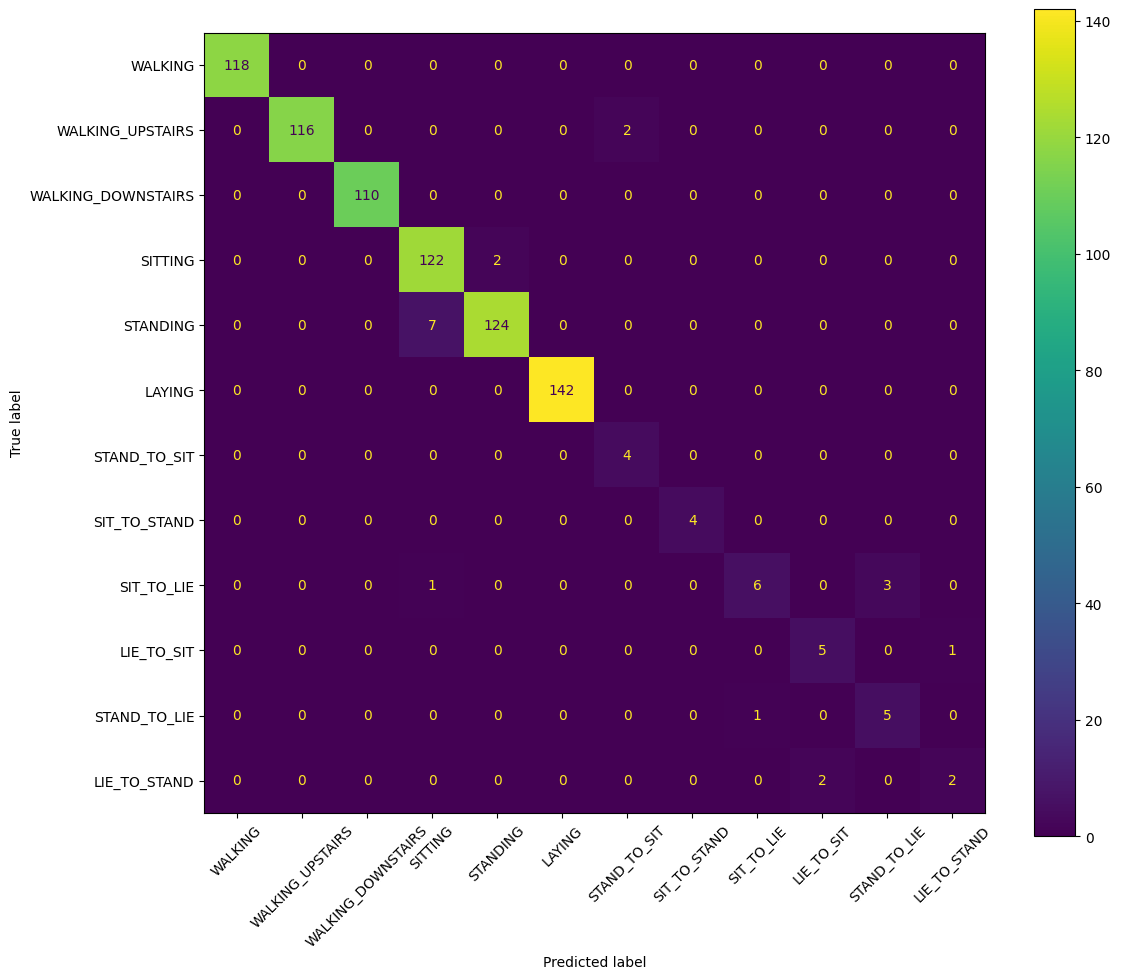

In [4]:
def compute_miou(cm):
    iou_per_class = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        iou_per_class.append(tp / denom if denom > 0 else 0.0)
    return np.mean(iou_per_class), iou_per_class

# Validation evaluation
y_val_pred  = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)

val_acc = (y_val_pred == y_val).mean()
print(f"\nValidation Accuracy: {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, target_names=ACTIVITY_LABELS))

auc_roc = roc_auc_score(y_val, y_val_proba, multi_class="ovr", average="macro")
print(f"Validation Macro AUC-ROC: {auc_roc:.4f}")

cm = confusion_matrix(y_val, y_val_pred)
miou, per_class_iou = compute_miou(cm)
print(f"Validation MIoU: {miou:.4f}")

disp = ConfusionMatrixDisplay(cm, display_labels=ACTIVITY_LABELS)
_, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

## Testing


Test Accuracy: 0.9307
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.94       496
  WALKING_UPSTAIRS       0.91      0.93      0.92       471
WALKING_DOWNSTAIRS       0.99      0.92      0.95       420
           SITTING       0.93      0.89      0.91       508
          STANDING       0.91      0.94      0.92       556
            LAYING       1.00      1.00      1.00       545
      STAND_TO_SIT       0.79      0.83      0.81        23
      SIT_TO_STAND       0.82      0.90      0.86        10
        SIT_TO_LIE       0.71      0.69      0.70        32
        LIE_TO_SIT       0.80      0.64      0.71        25
      STAND_TO_LIE       0.71      0.71      0.71        49
      LIE_TO_STAND       0.69      0.74      0.71        27

          accuracy                           0.93      3162
         macro avg       0.85      0.85      0.85      3162
      weighted avg       0.93      0.93      0.93      3162

Test Macro AUC

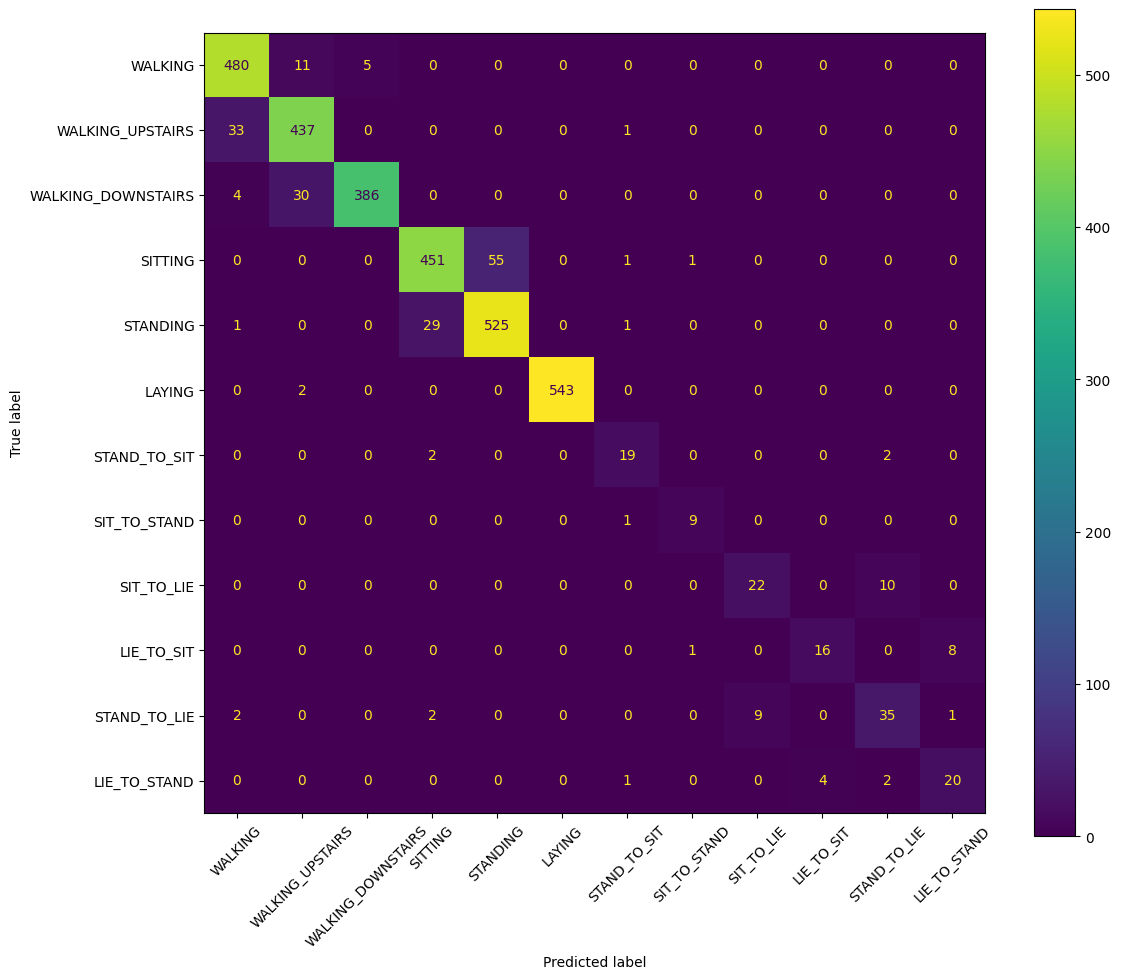

In [23]:
# Test evaluation
y_test_pred  = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)

test_acc = (y_test_pred == y_test).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_test_pred, target_names=ACTIVITY_LABELS))